# FTIML Assignment 2: Fairness (10 points)

## Dataset: 2021 British Columnbia (Canada) Census data

The dataset represents the 2021 British Columbia (Canada) Census data. Each row describes the demographic and socioeconomic characteristics of an individual. The objective is to predict whether an individual's income exceeds 75K. These predictions will be used by a company that determines loan approvals based on your model's output. An individual's income may be influenced by their demographic and socioeconomic attributes. However, the company is legally prohibited from engaging in unfair treatment on the basis of "race, national or ethnic origin, colour, religion, age, sex, sexual orientation, gender identity or expression, marital status, family status, genetic characteristics, disability, or conviction for an offence for which a pardon has been granted or in respect of which a record suspension has been ordered", as outlined in the Canadian Human Rights Act. Your task is to analyze the fairness of your model's predictions and to apply techniques to improve the fairness of your models.

See for more information on the dataset "2021 Census Individuals PUMF User Guide.pdf". You are not required to read the entire document. 

Hint: Unavailable data is often encoded by 88888888 or 99999999.

## Deliverable:

A **.zip file** containing two elements: 
1. The **Jupyter notebook** you used for your analysis of Tasks a - d below (in ipynb).  
2. A **report of max. 4 pages** with the complete answers to the questions below (in pdf). 

**DEADLINE: Monday May 11, 2026 at 23:59.**

Note: All information in 2. needs to be contained in 1. (not necessarily vice versa).

Note: The grade for the assignment is primarily based on your presentation on May 12 and your report. The notebook serves as an add-on.


## Task a: Data Exploration
Before entering the analysis, spend some time to understand the data. 

* Which features do you expect to influence fairness?
* Define groups based on the sensitive feature(s) and visualize the data.
* Are there any inbalances? How might these affect your fairness analysis? 

Use graphs and/or tables, and write down your observations. 


## Task b: Explore Fairness
Take the outcomes of a black-box model (you may use the random forest model fitted below or for example a XGBoost model, neural network, ...) and an interpretable model of your choice and analyze their fairness across different protected groups.

*   Choose and report three group fairness metrics that are useful for the given context and report them.
*   Do you find evidence for biases in the models? Which group(s) appear to be at a disadvantage?
*   Are there any differences in fairness metrics between the black-box and interpretable models?

Use visualizations to support your analysis. Summarize the results in text. 


## Task c: Individual Fairness
Try to improve the fairness of your models using two individual fairness techniques.

Refer to the lecture slides and the notebook from the fairness tutorial for guidance on what is expected here.

Clearly state the techniques you are using and elaborate on their effects on the fairness of the models.


## Task d: Group Fairness
Try to improve the fairness metrics of your models using two group fairness techniques.

Explain why you choose the techniques you are using and elaborate on their effects on the fairness of the models.


# Preparations

## Install and load libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_curve, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns

## Load and preprocess data
**Do not change this part**

In [2]:
data = pd.read_csv('data_donnees_2021_ind_BC.csv')
# print columns all column s
print(list(data.columns))

['PPSORT', 'ABOID', 'AGEGRP', 'AGEIMM', 'ATTSCH', 'BFNMEMB', 'BEDRM', 'CFSTAT', 'CHDBN', 'CIP2021', 'CIP2021_STEM_SUM', 'CMA', 'CONDO', 'COVID_ERB', 'COW', 'CQPPB', 'CfSize', 'ChldC', 'CitOth', 'Citizen', 'DIST', 'DPGRSUM', 'DTYPE', 'EFDecile', 'EFInc', 'EFInc_AT', 'EICBN', 'ETHDER', 'EfDIMBM_2018', 'EfSize', 'FOL', 'FPTWK', 'Gender', 'GENSTAT', 'GTRfs', 'HCORENEED_IND', 'HDGREE', 'HHSIZE', 'HHTYPE', 'HLMOSTEN', 'HLMOSTFR', 'HLMOSTNO', 'HLREGEN', 'HLREGFR', 'HLREGNO', 'IMMCAT5', 'IMMSTAT', 'JOBPERM', 'KOL', 'LFACT', 'LICO_BT', 'LICO_AT', 'LIPROGTYPE', 'LI_ELIG_OML_U18', 'LOCSTUD', 'LOC_ST_RES', 'LSTWRK', 'LWMOSTEN', 'LWMOSTFR', 'LWMOSTNO', 'LWREGEN', 'LWREGFR', 'LWREGNO', 'LoLIMA', 'LoLIMB', 'LOMBM_2018', 'MODE', 'MTNEn', 'MTNFr', 'MTNNO', 'MARSTH', 'Mob1', 'Mob5', 'NAICS', 'NOC21', 'NOS', 'OASGI', 'PKID25', 'PKID0_1', 'PKID15_24', 'PKID2_5', 'PKID6_14', 'PKIDS', 'POB', 'POBPAR1', 'POBPAR2', 'POWST', 'PR1', 'PR5', 'PRESMORTG', 'PRIHM', 'PWDUR', 'PWLEAVE', 'PWOCC', 'PWPR', 'REGIND', 'RE

In [3]:
# Remove identifiers and weights
drop_cols = ['PPSORT'] + ['WEIGHT'] + [f'WT{i}' for i in range(1, 17)]

# all variables directly derived from income, possible issue
leakage_cols = ['LICO_BT', 'LICO_AT', 'LoLIMA', 'LoLIMB', 'LIPROGTYPE', 
                'LI_ELIG_OML_U18', 'EFInc', 'EFInc_AT', 'EFDecile']

# Sensitive attributes
sensitive_cols = ['AGEGRP', 'Gender', 'VISMIN', 'RELIGION_DER', 
                  'IMMSTAT', 'ABOID', 'MARSTH']

# data = data.drop(columns=drop_cols + leakage_cols)
data = data.drop(columns=drop_cols)

In [4]:
# fixing all 88888888 to the mean/ mode and 999999999 to -1
data.replace(88888888, np.nan, inplace=True)
data.replace(99999999, -1, inplace=True)

# Identify column types
exclude = ["SHELCO", "75k"] # non categorical variables
cat_cols = [col for col in data.columns if data[col].nunique() < 60 and col not in exclude]
num_cols = [col for col in data.columns if col not in cat_cols]

# all categorical features use 8, 88, or 888 for unavailable data
def get_sentinel(col_max, num_str):
    for sentinel in [int(num_str), int(num_str*2), int(num_str*3), int(num_str*4)]:
        if sentinel >= col_max:
            return sentinel
    return None

for col in cat_cols:
    col_max = data[col].max()
    sentinel = get_sentinel(col_max, "9")
    if sentinel is not None and (data[col] == sentinel).any():
        print(f"{col}: max={col_max}, replacing {sentinel} with -1")
        data[col] = data[col].replace(sentinel, -1)

    col_max = data[col].max()
    sentinel = get_sentinel(col_max, "8")
    if sentinel is not None and (data[col] == sentinel).any():
        print(f"{col}: max={col_max}, replacing {sentinel} with NaN")
        data[col] = data[col].replace(sentinel, np.nan)

# Impute the 88888888 values
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

for col in num_cols:
    data[col] = data[col].fillna(data[col].mean())

AGEIMM: max=99, replacing 99 with -1
ATTSCH: max=8, replacing 8 with NaN
BEDRM: max=8, replacing 8 with NaN
CFSTAT: max=8, replacing 8 with NaN
CIP2021: max=88, replacing 88 with NaN
CIP2021_STEM_SUM: max=88, replacing 88 with NaN
CMA: max=999, replacing 999 with -1
CONDO: max=8, replacing 8 with NaN
COW: max=9, replacing 9 with -1
COW: max=8, replacing 8 with NaN
CfSize: max=8, replacing 8 with NaN
CitOth: max=88, replacing 88 with NaN
DIST: max=9, replacing 9 with -1
DPGRSUM: max=88, replacing 88 with NaN
DTYPE: max=8, replacing 8 with NaN
EfSize: max=8, replacing 8 with NaN
FPTWK: max=9, replacing 9 with -1
GENSTAT: max=8, replacing 8 with NaN
HCORENEED_IND: max=888, replacing 888 with NaN
HDGREE: max=88, replacing 88 with NaN
HHSIZE: max=8, replacing 8 with NaN
HHTYPE: max=88, replacing 88 with NaN
HLMOSTEN: max=8, replacing 8 with NaN
HLMOSTFR: max=8, replacing 8 with NaN
HLMOSTNO: max=88, replacing 88 with NaN
HLREGEN: max=8, replacing 8 with NaN
HLREGFR: max=8, replacing 8 with 

In [5]:
data = data.copy()
data = data.assign(
    under30 = data['AGEGRP'] <= 9,
    thridgenorhigher = data['GENSTAT'] == 4,
    isacitizen = data['Citizen'] != 3,
    isreligious = data['RELIGION_DER'] == 22,
    Gender_Female = data['Gender'] == 1,
)

In [6]:
# get features and target
AGEGRP = data['AGEGRP'] # this serves as an example, you can choose other sensitive attributes
X = pd.get_dummies(data.drop(columns=["75k"]))
y = data["75k"]

## Exploratory data analysis and feature engineering
Inspect the data and do some plots that help you understand the dataset here.

**Optional**: The dataset is already preprocessed. However, it might still pay off to invest some time in additional preprocessing here here (scaling, feature engineering, ...). This might improve model quality and help to rectify modeling errors.

**Note**: The data is imbalanced.

In [7]:
print(y.value_counts())

75k
0    44476
1    12014
Name: count, dtype: int64


### Exploration of sensitive attributes
---
Given the senstive attributes we have constructed 4 groups:
1. age under 30
2. third generation or higher
3. citizenship
4. Christian

                                             |          | [  0%]   00:00 -> (? left)


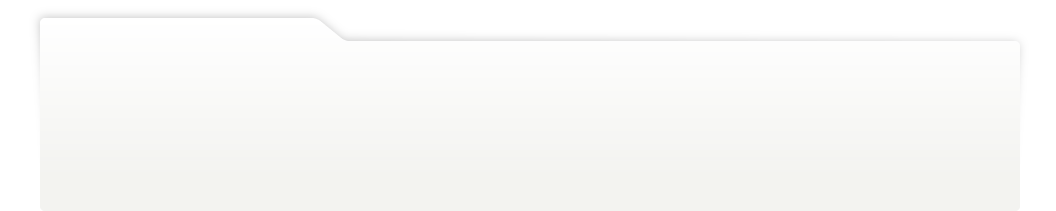
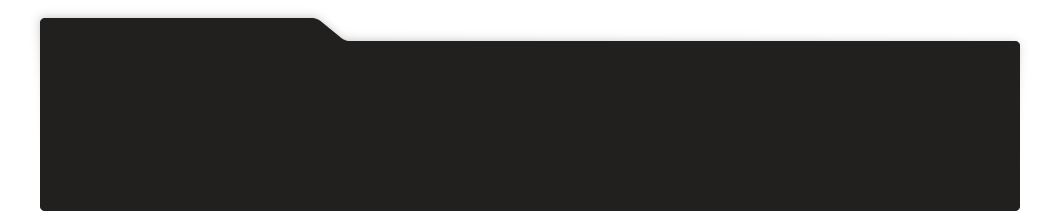
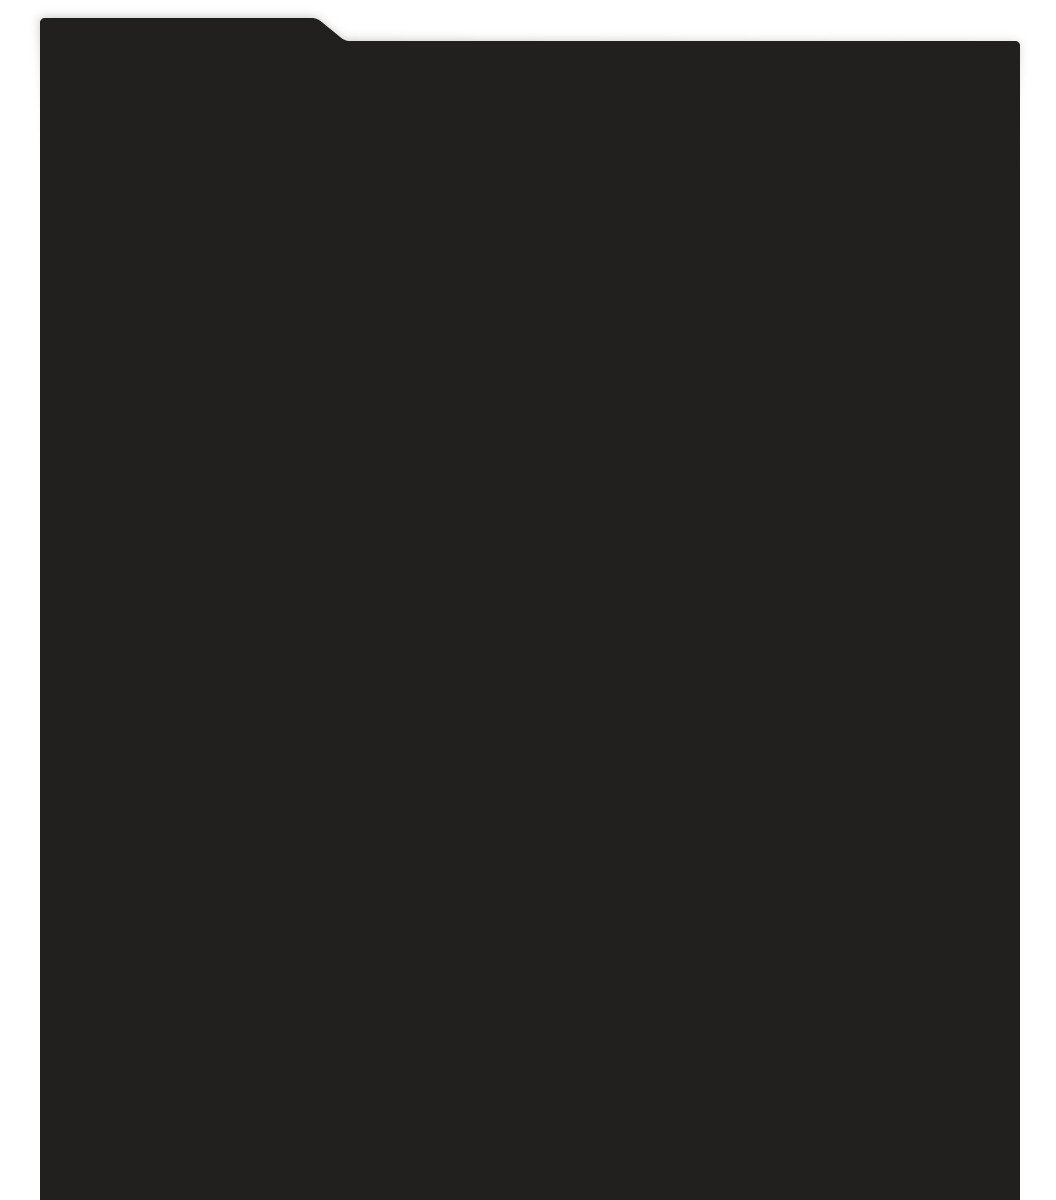
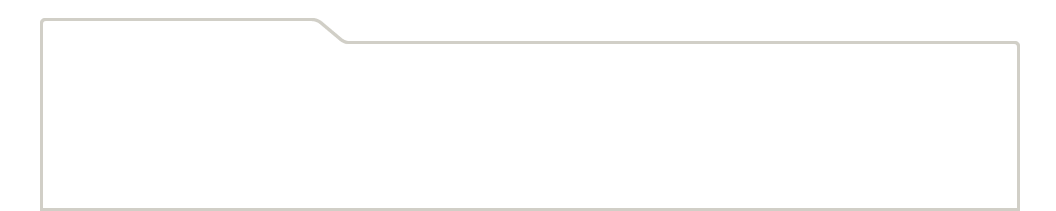
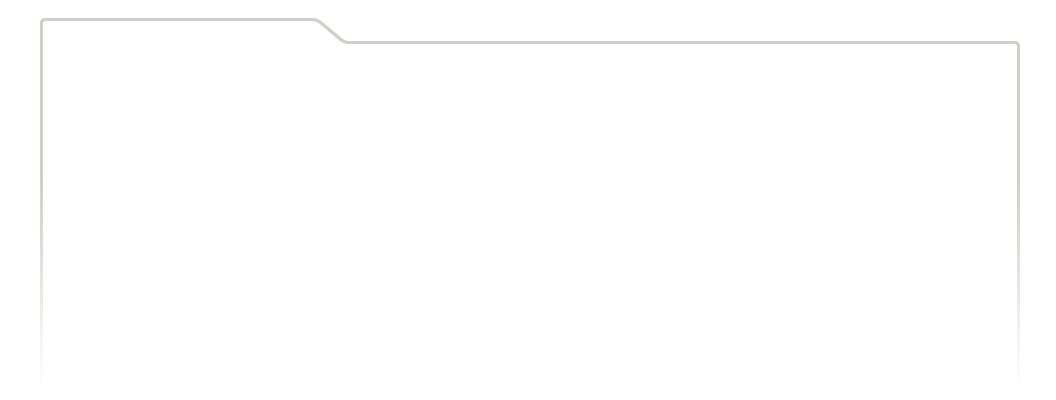
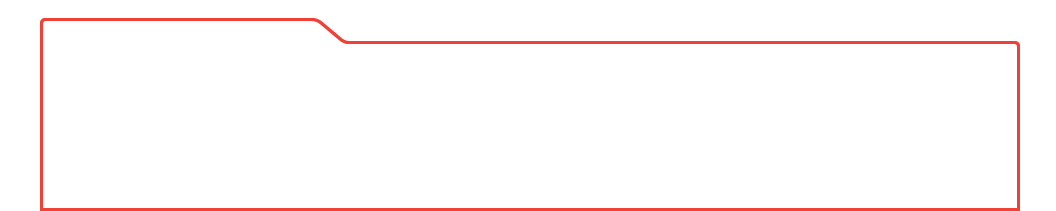
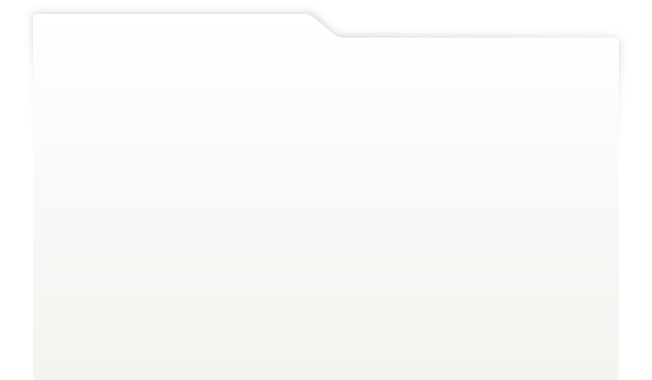
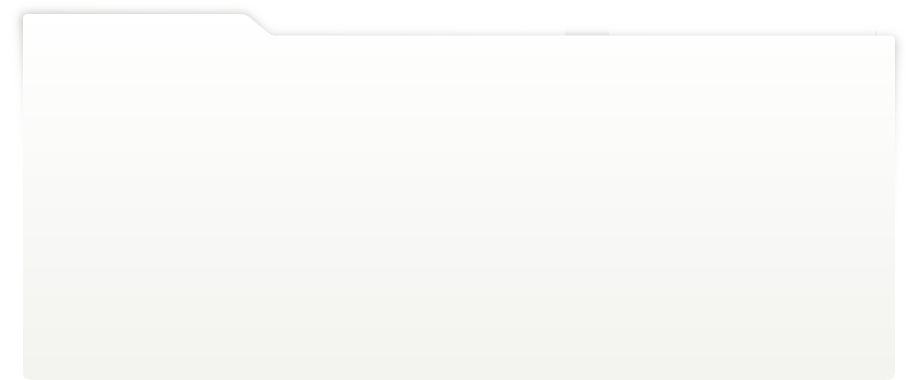
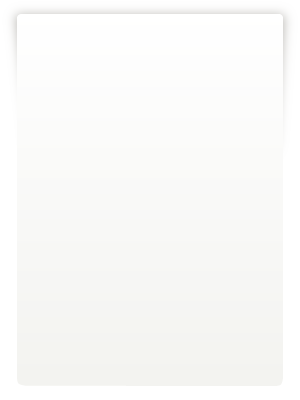
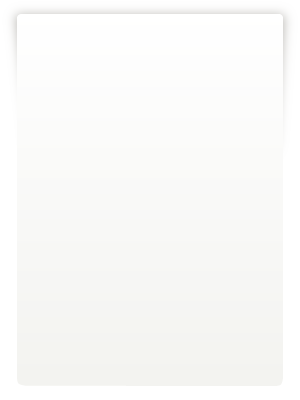
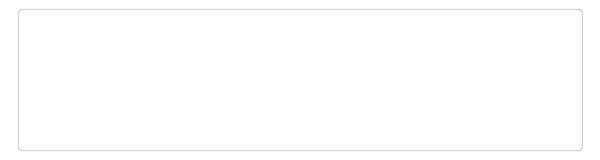
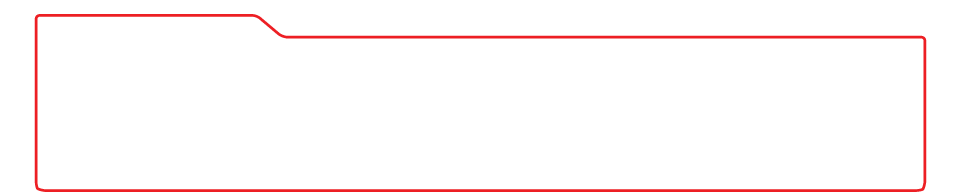
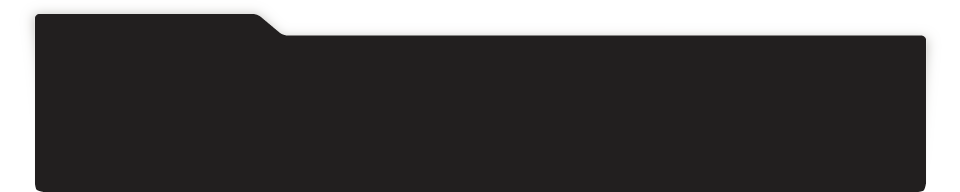
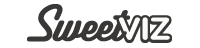
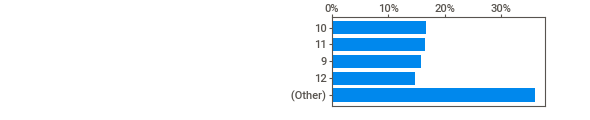
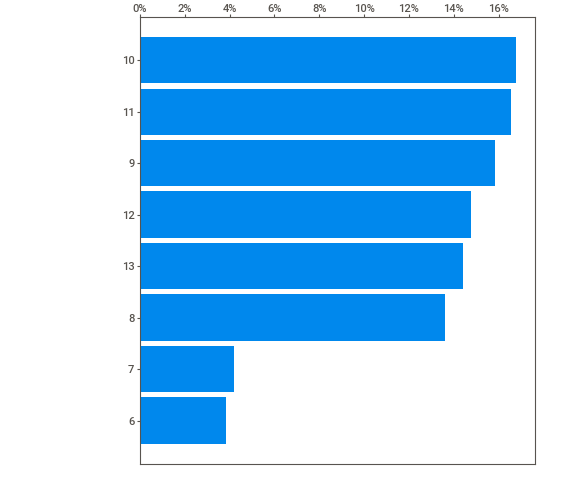
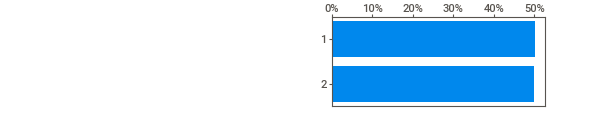
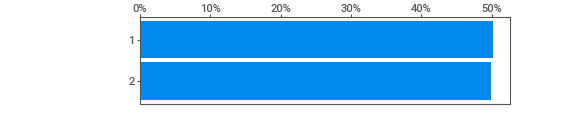
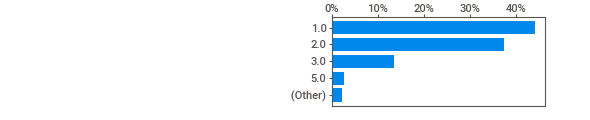
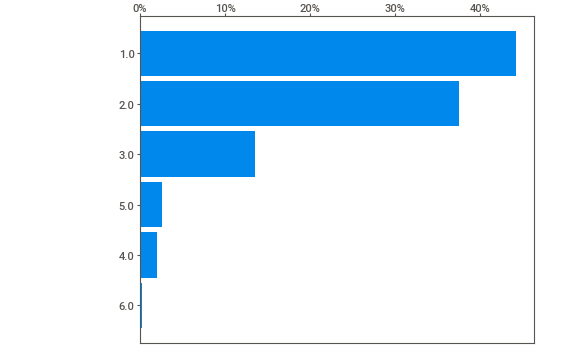
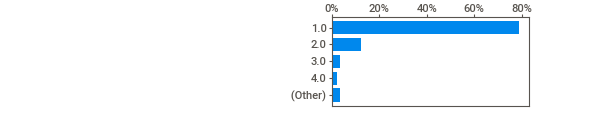
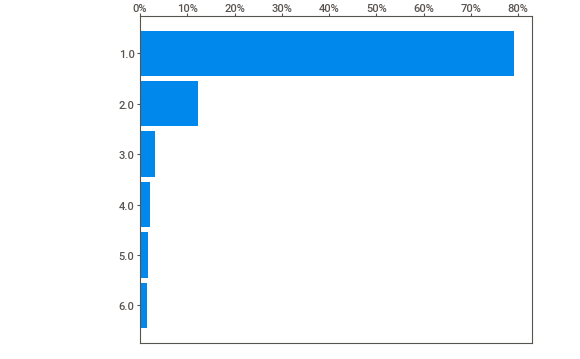
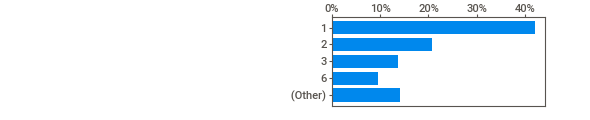
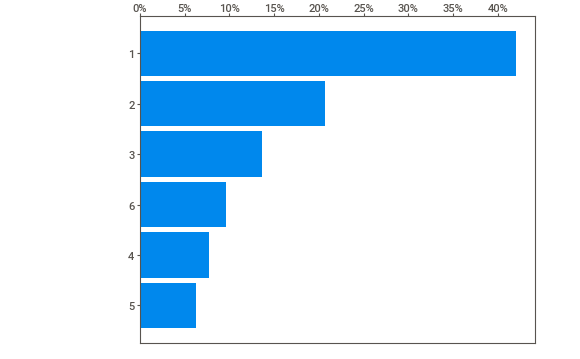
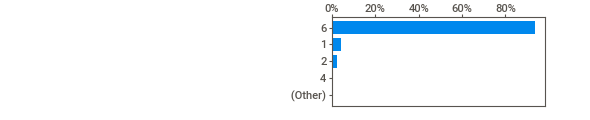
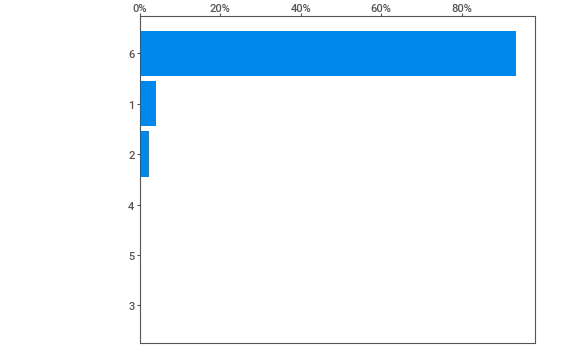
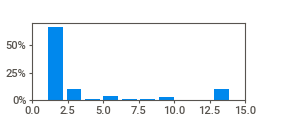
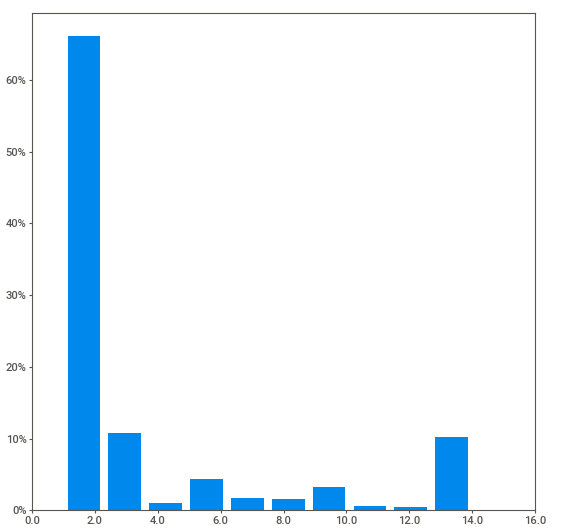
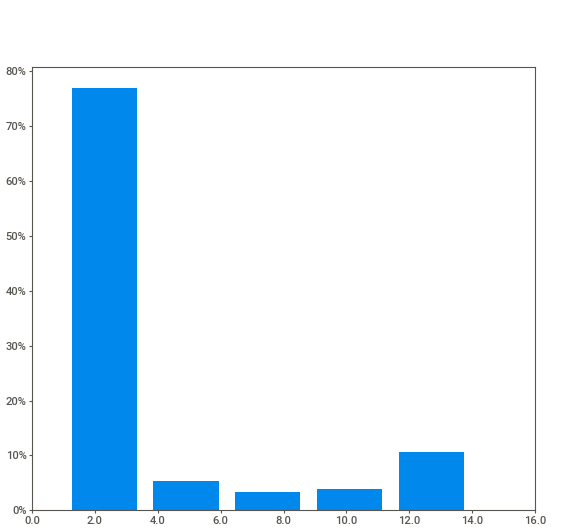
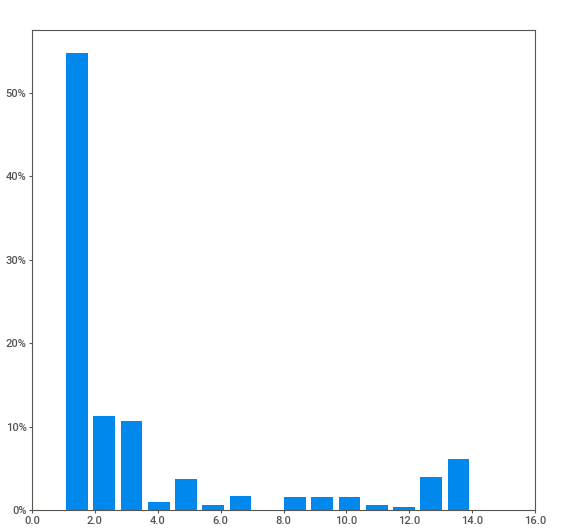
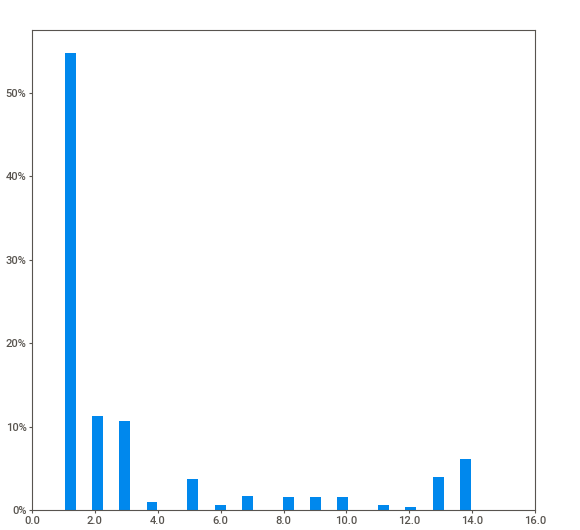
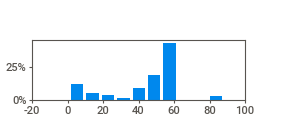
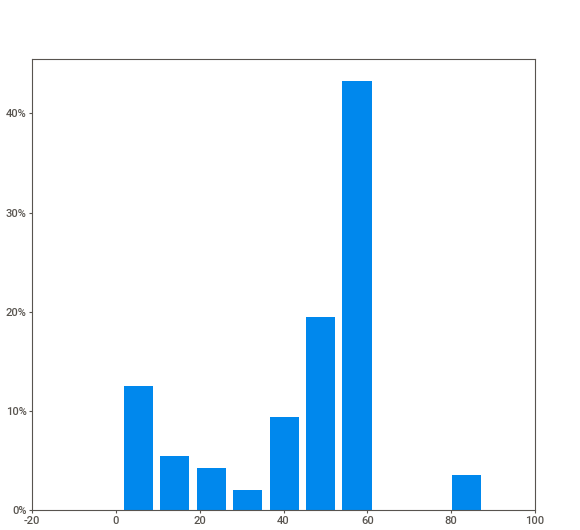
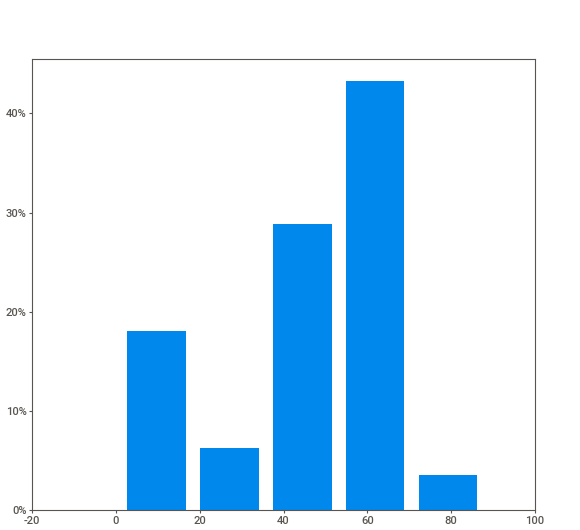
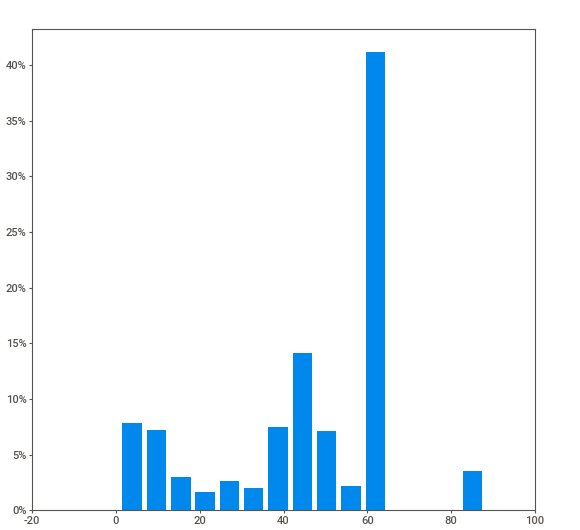
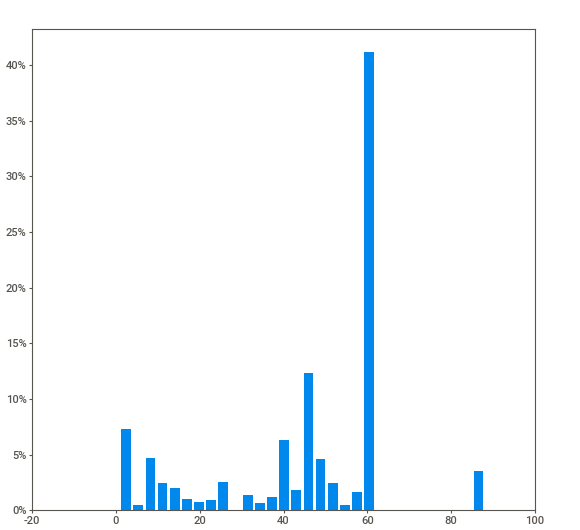
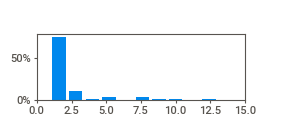
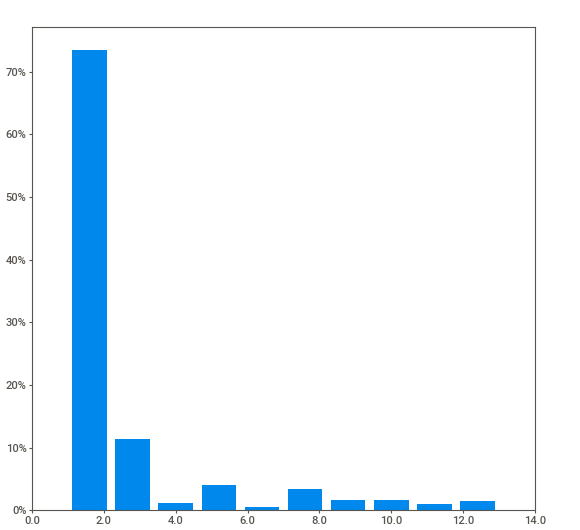
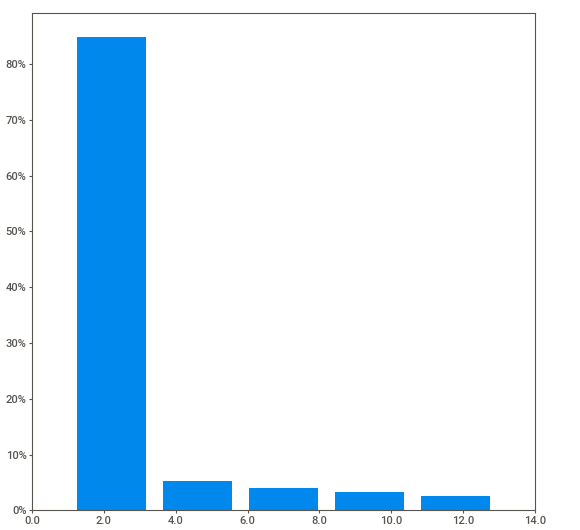
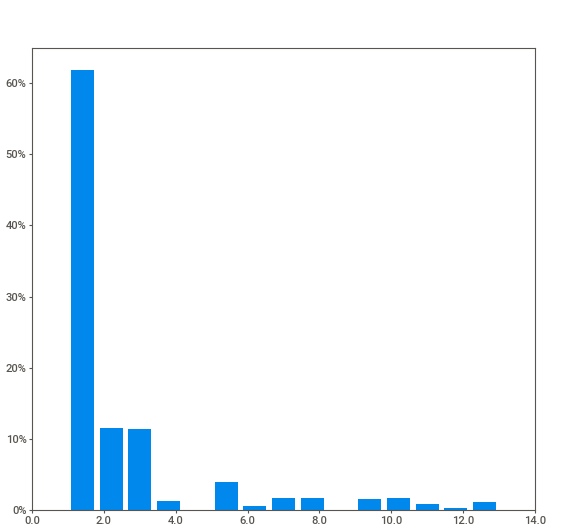
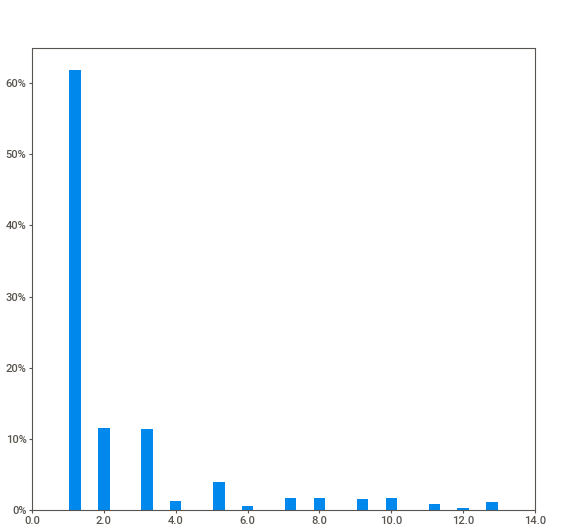
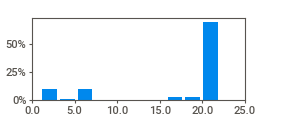
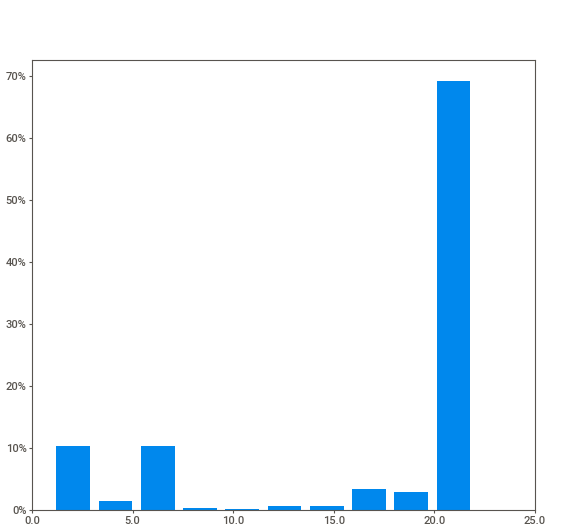
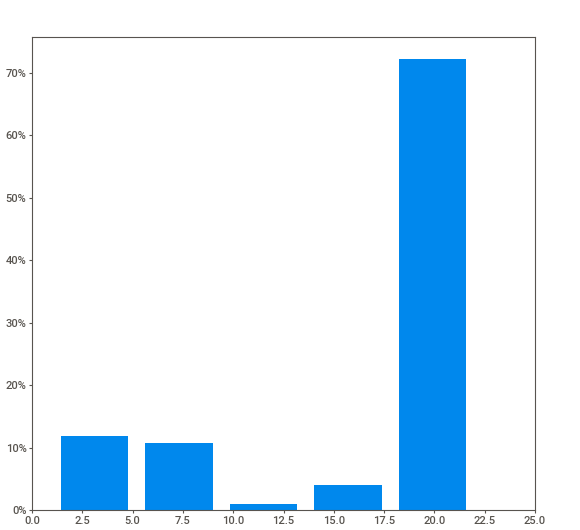
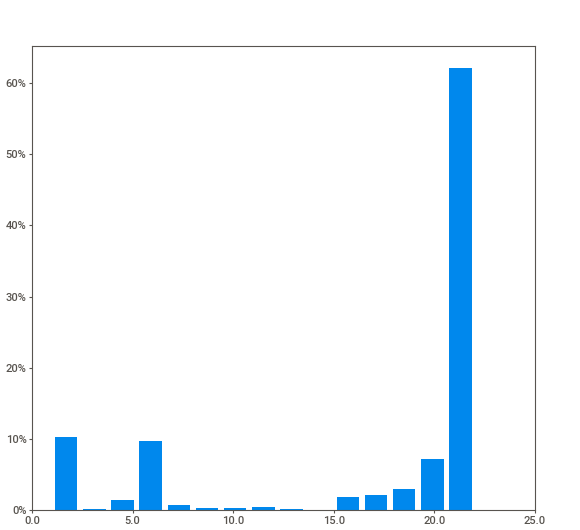
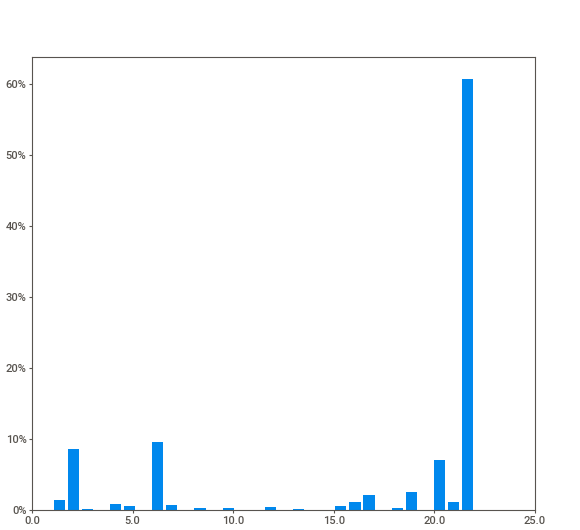
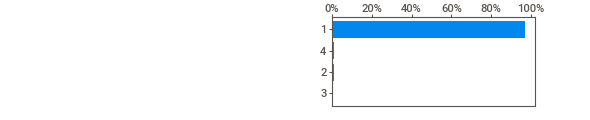
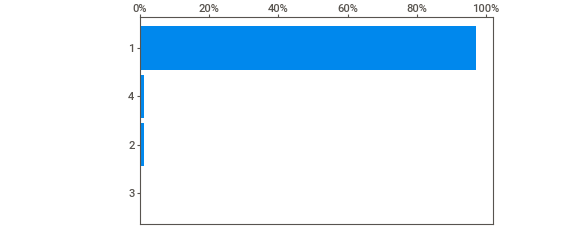
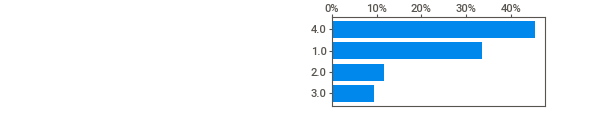
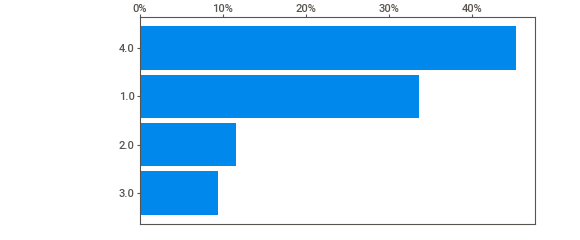
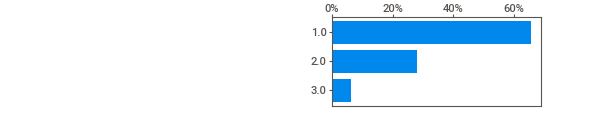
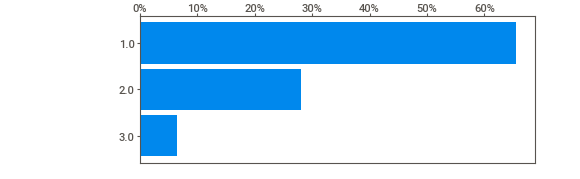
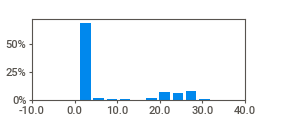
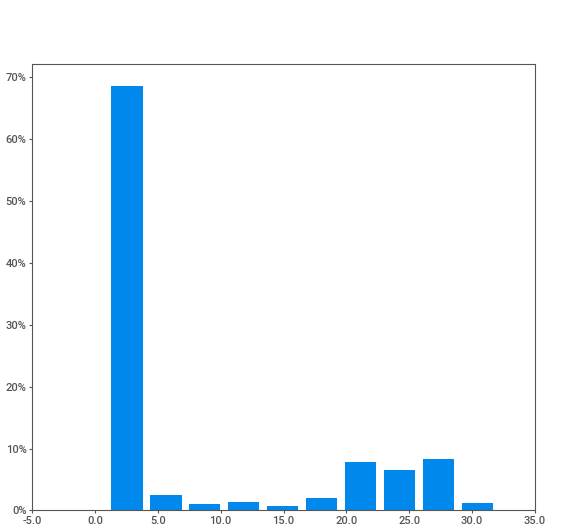
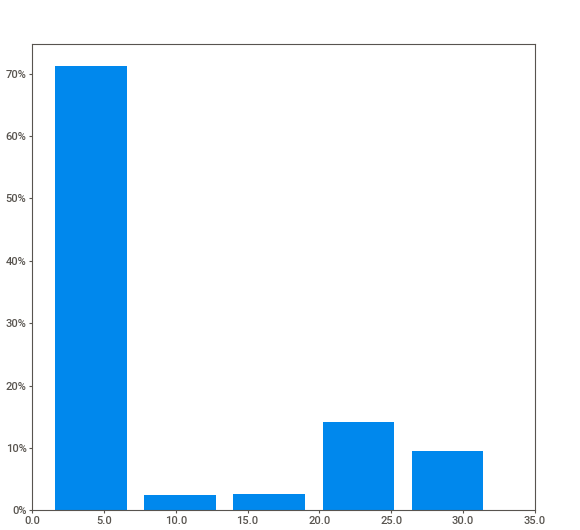
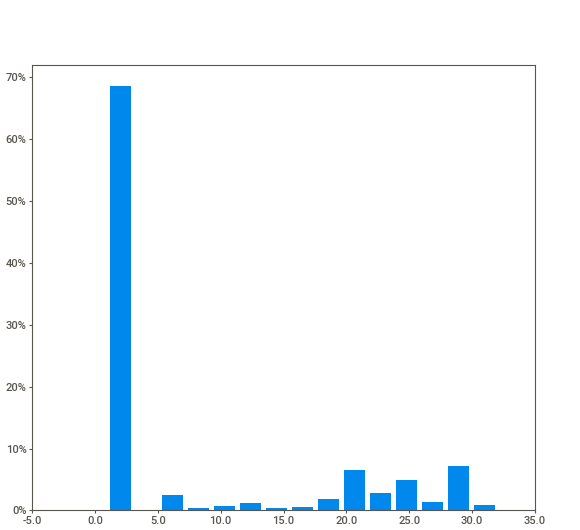
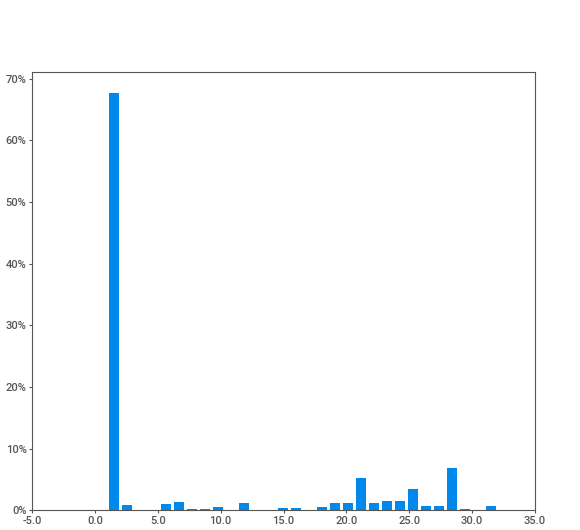
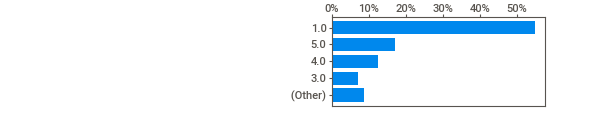
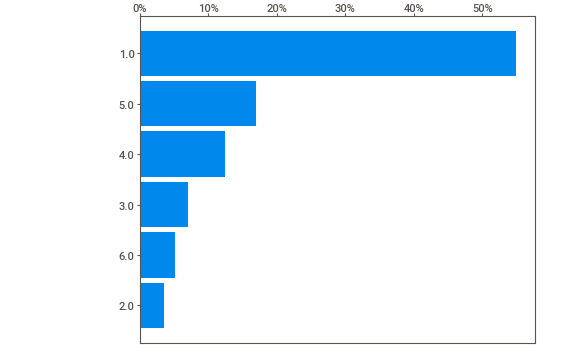
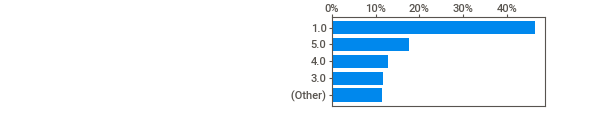
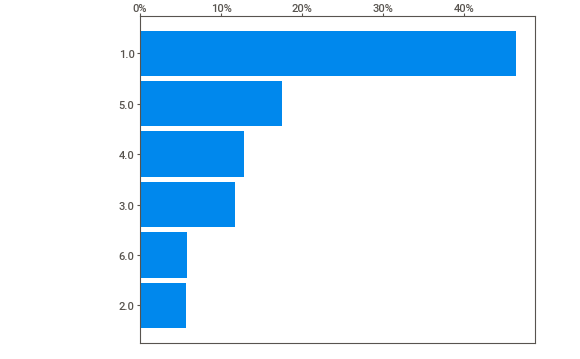
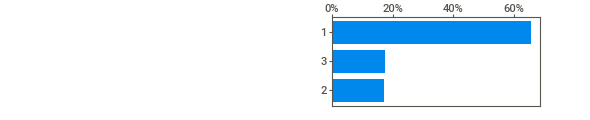
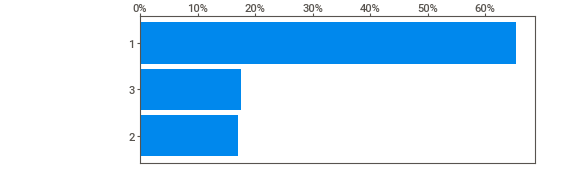
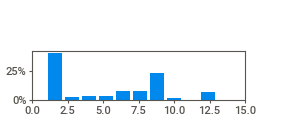
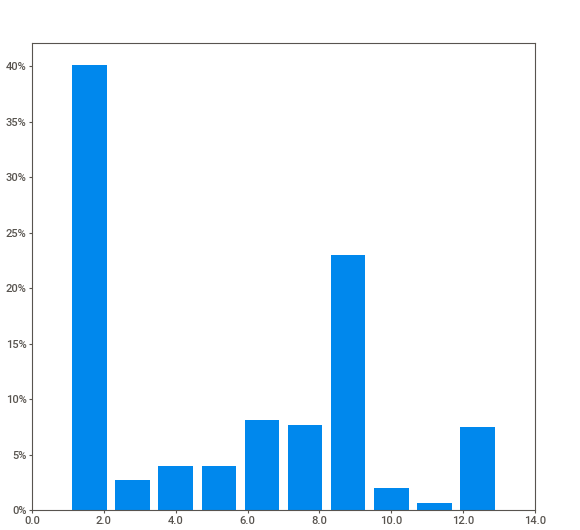
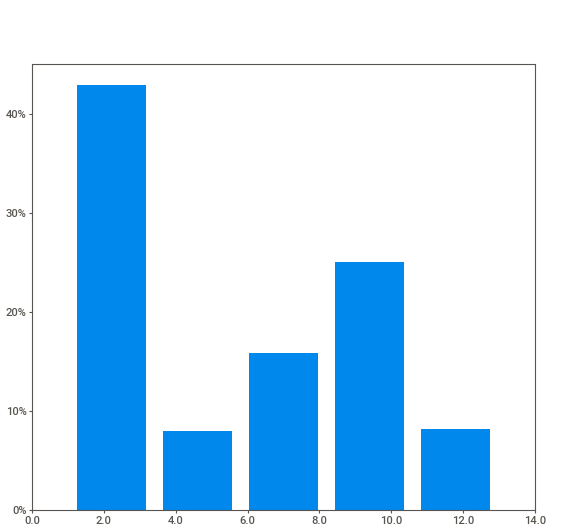
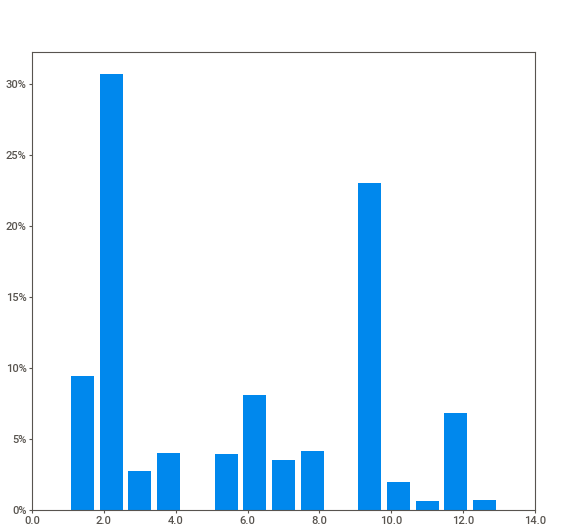
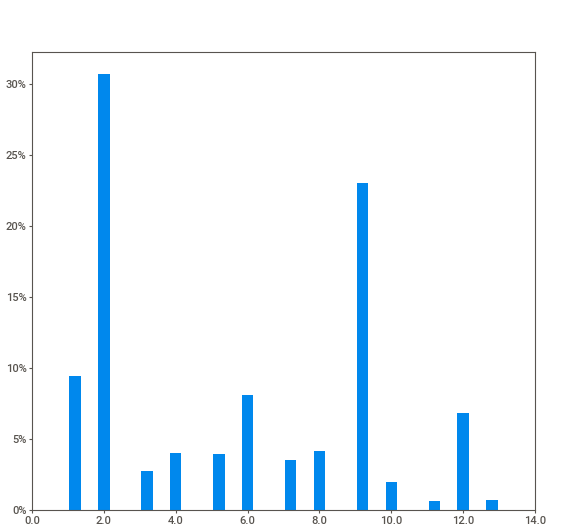
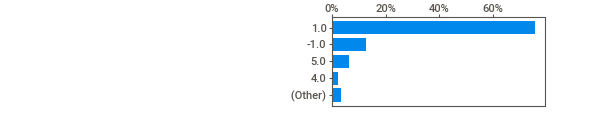
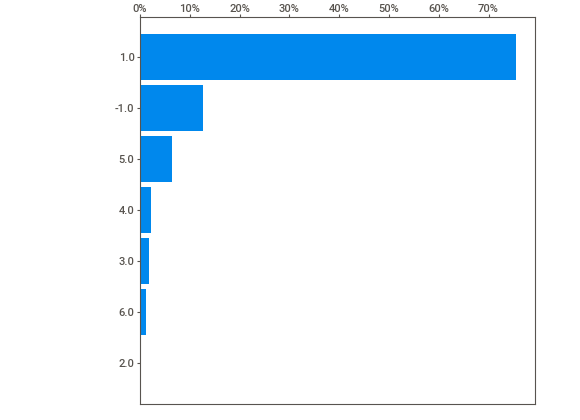
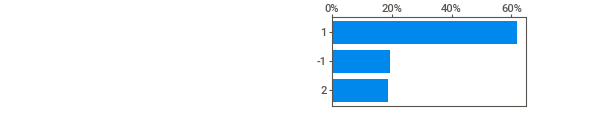
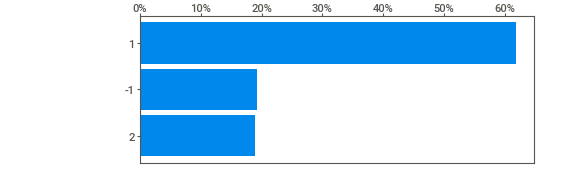
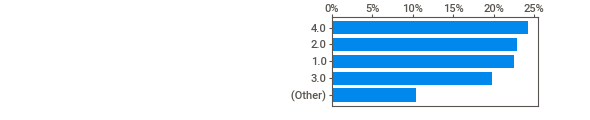
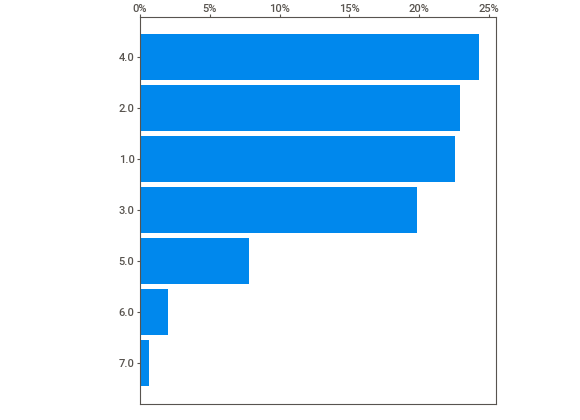
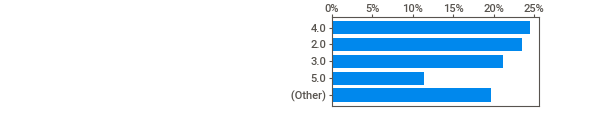
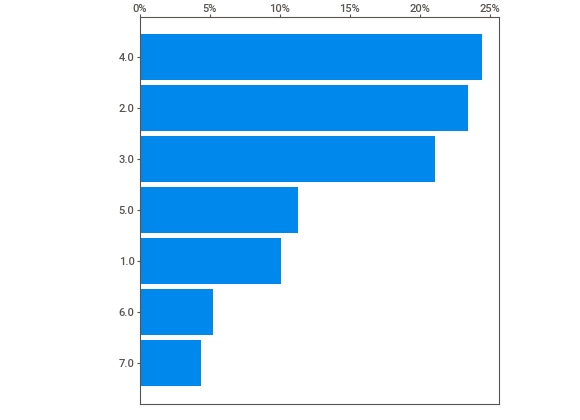
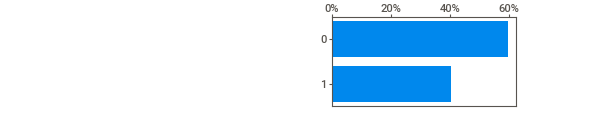
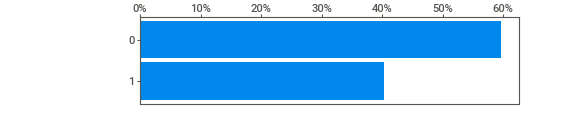
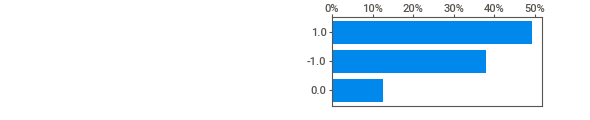
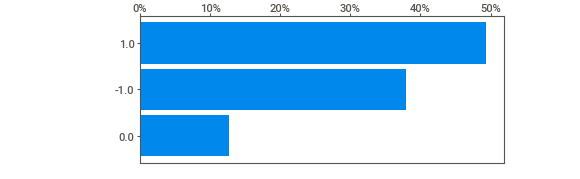
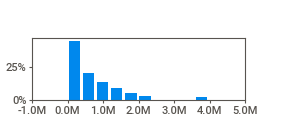
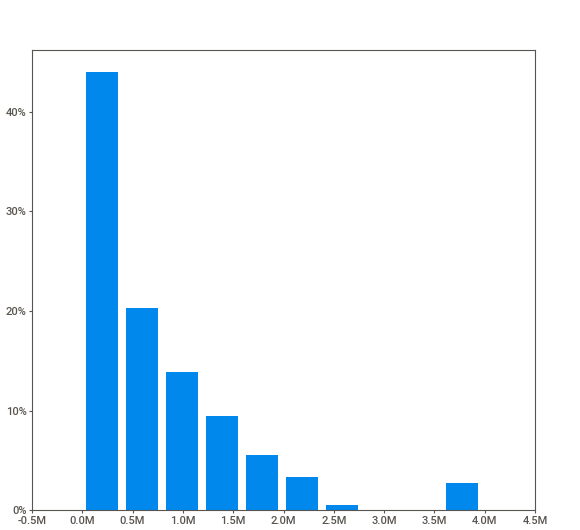
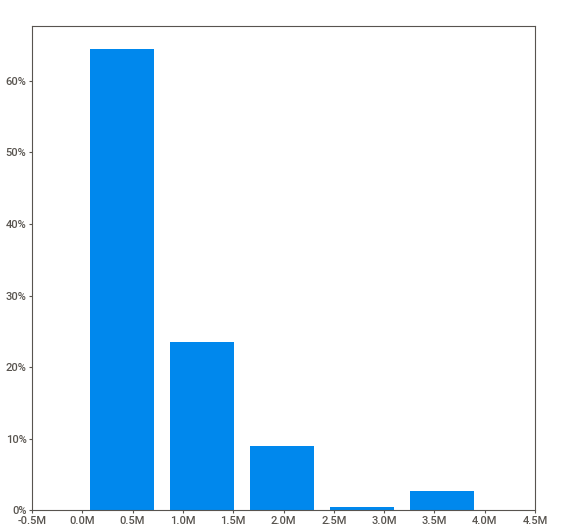
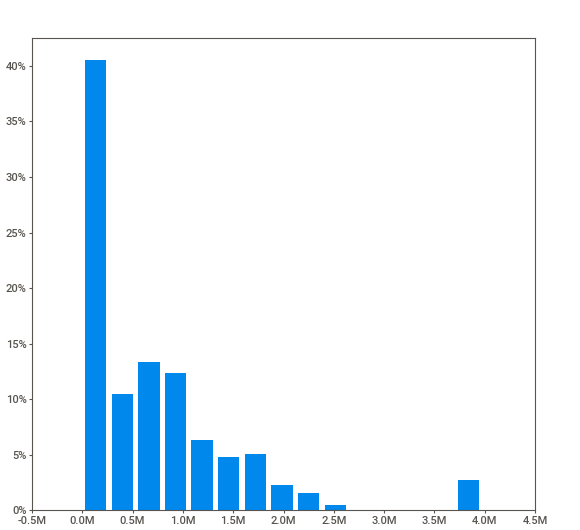
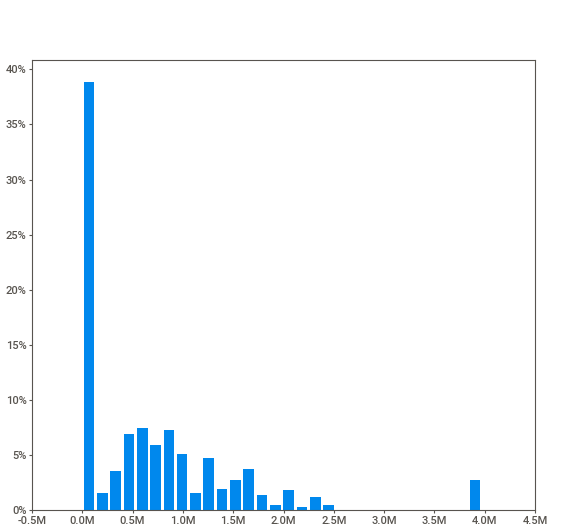
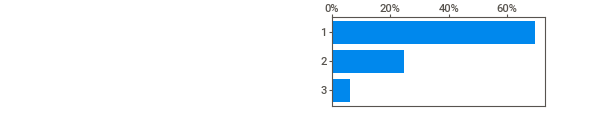
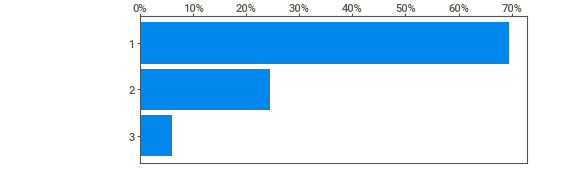
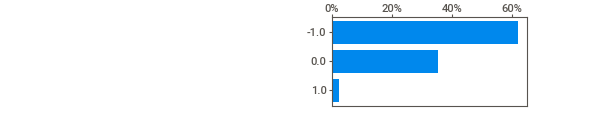
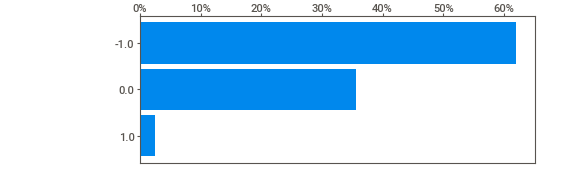
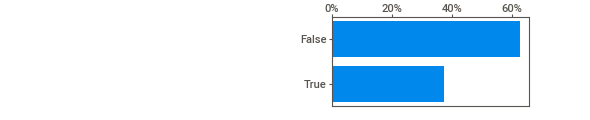
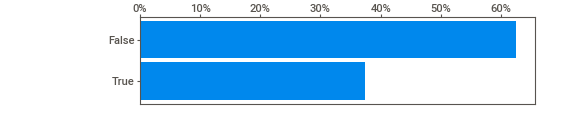
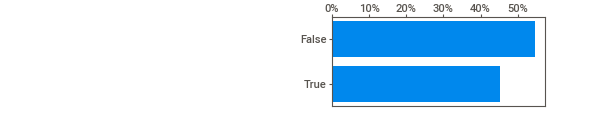
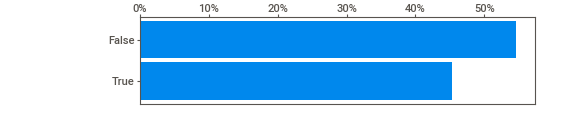
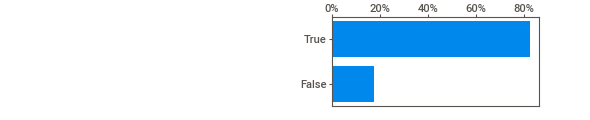
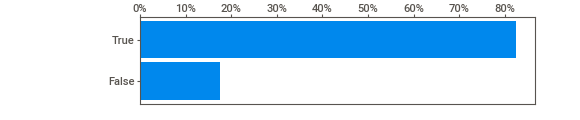
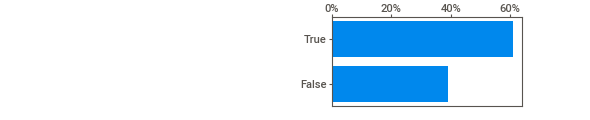
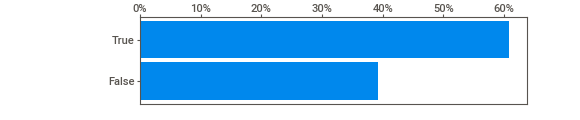
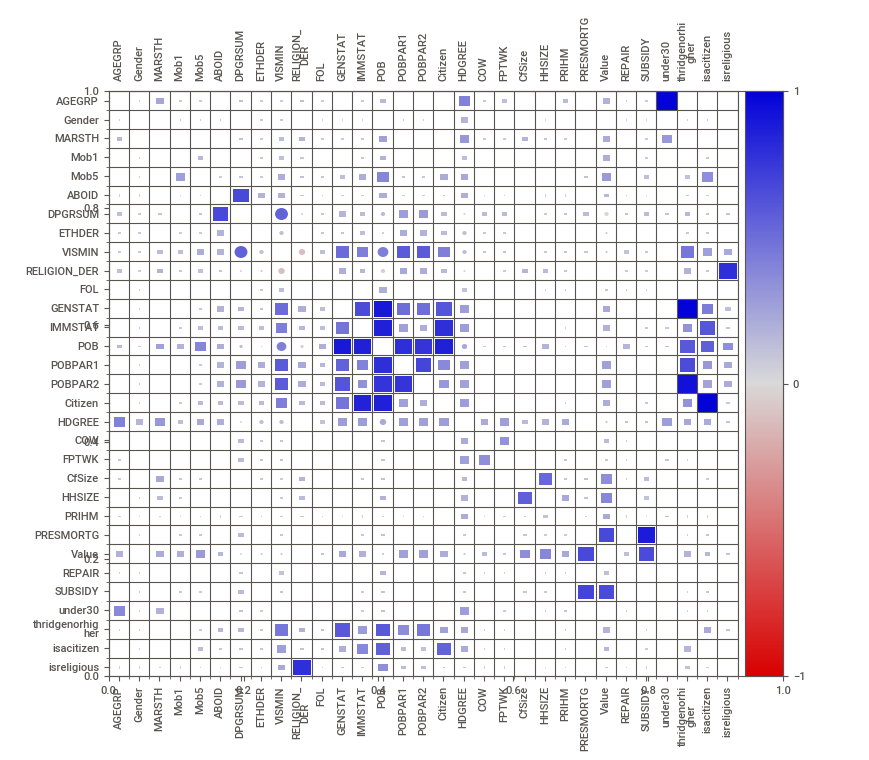
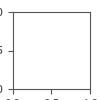

In [8]:
import sweetviz as sv # pip install sweetviz

# fairness_vars = ['Gender', 'VISMIN', 'ABOID', 'AGEGRP', 'RELIGION_DER', 'MARSTH',
#                  'ETHDER', 'IMMSTAT', 'GENSTAT', 'POB', 'POBPAR1', 'POBPAR2', 'Citizen']

fairness_vars = ['AGEGRP', 'Gender', 'MARSTH', # demography
                 'Mob1', 'Mob5', #mobility
                 'ABOID', #indegenous population
                 'DPGRSUM', 'ETHDER', 'VISMIN', # ethnic or cultural origin
                 'RELIGION_DER', # religion
                 'FOL', #language
                 'GENSTAT', 'IMMSTAT', 'POB', 'POBPAR1', 'POBPAR2', 'Citizen', # place of birth
                 'HDGREE', # education
                 'COW', 'FPTWK', # labour market
                 'CfSize', # families and family compsition
                 'HHSIZE', 'PRIHM', #households
                 'PRESMORTG', 'Value', 'REPAIR', 'SUBSIDY', # Dwelling
                 'under30', 'thridgenorhigher', 'isacitizen', 'isreligious']

report = sv.analyze(X[fairness_vars])
report.show_notebook()

<Axes: xlabel='isreligious', ylabel='75k'>

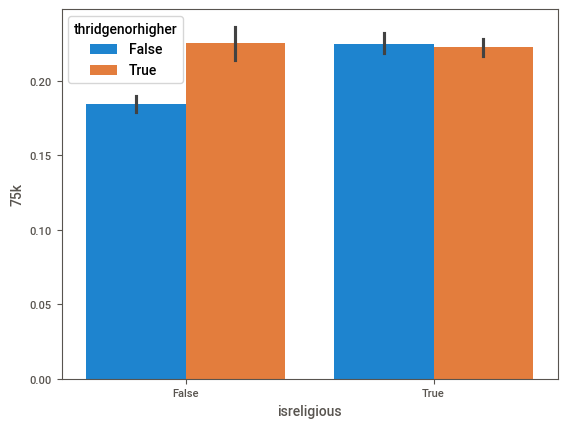

In [9]:
sns.barplot(x='isreligious', y='75k', hue='thridgenorhigher', data=data)

<Axes: xlabel='under30', ylabel='75k'>

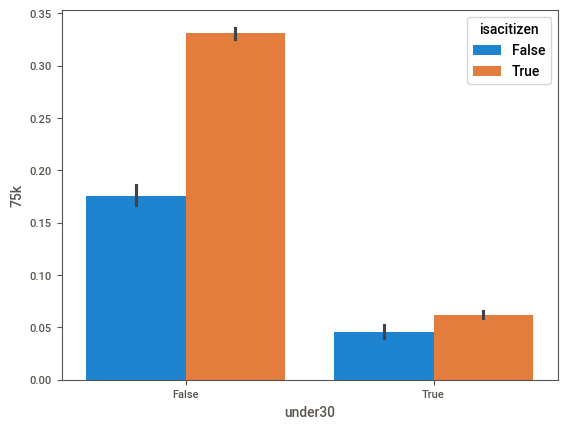

In [10]:
sns.barplot(x='under30', y='75k', hue='isacitizen', data=data)

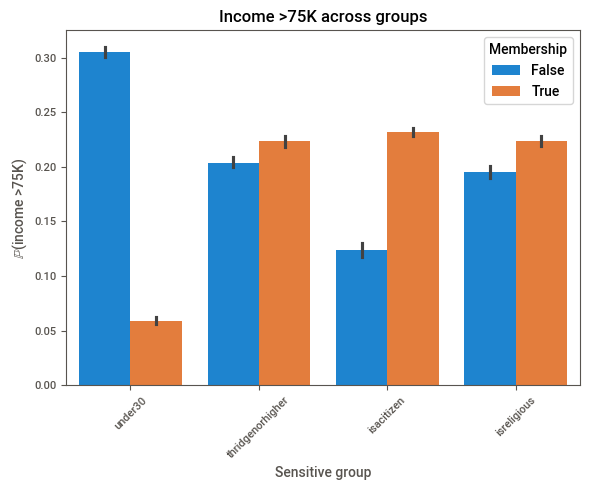

In [11]:
df_long = data.melt(
    id_vars=['75k', 'Gender_Female'],
    value_vars=['under30', 'thridgenorhigher', 'isacitizen', 'isreligious'],
    var_name='group',
    value_name='membership'
)
plt.figure(figsize=(6,5))

sns.barplot(
    data=df_long,
    x='group',
    y='75k',
    hue='membership',
)

plt.ylabel(r"$\mathbb{P}$(income >75K)")
plt.xlabel("Sensitive group")
plt.title("Income >75K across groups")
plt.xticks(rotation=45)
plt.legend(title="Membership")
plt.tight_layout()
plt.show()

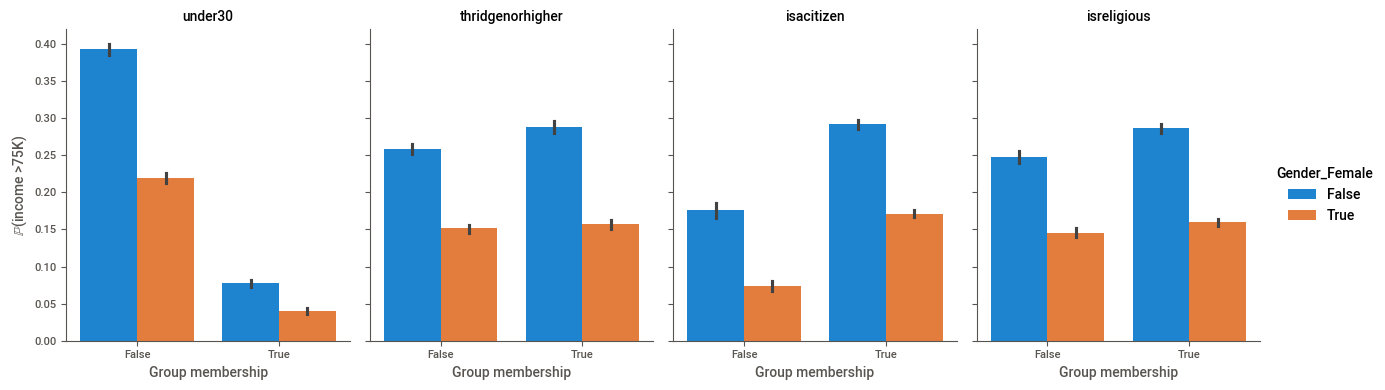

In [12]:
g = sns.catplot(
    data=df_long,
    x='membership',
    y='75k',
    hue='Gender_Female',
    col='group',
    kind='bar',
    height=4,
    aspect=0.8,
    sharey=True
)

g.set_titles("{col_name}")
g.set_axis_labels("Group membership", r"$\mathbb{P}$(income >75K)")
plt.show()

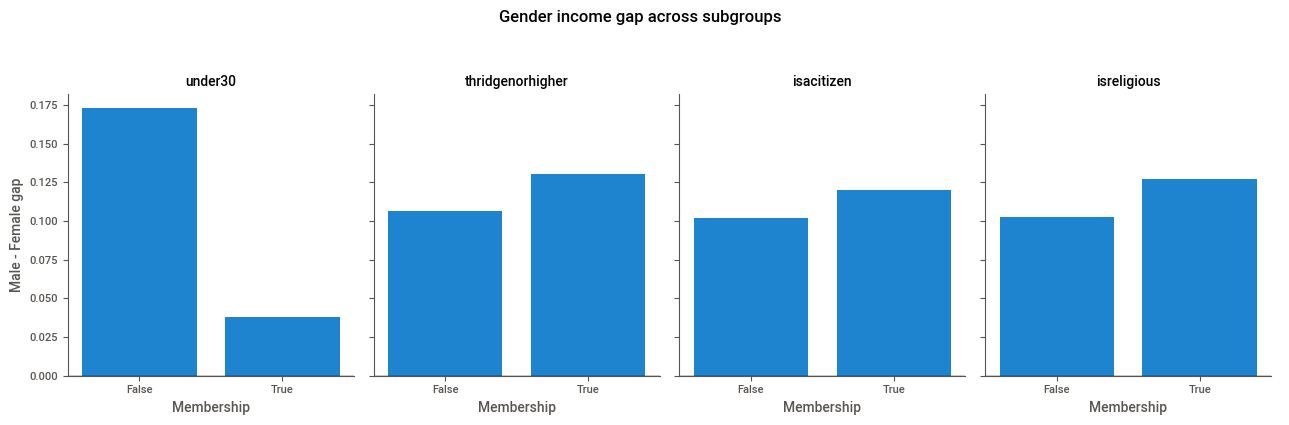

In [13]:
results = []
for col in ['under30', 'thridgenorhigher', 'isacitizen', 'isreligious']:
    grouped = data.groupby([col, 'Gender_Female'])['75k'].mean().unstack()
    grouped['gap'] = grouped[False] - grouped[True]
    for val in grouped.index:
        results.append({ 'group': col, 'membership': val, 'gender_gap': grouped.loc[val, 'gap'] })
gap_df = pd.DataFrame(results)

g = sns.catplot(
    data=gap_df,
    x='membership',
    y='gender_gap',
    col='group',
    kind='bar',
    height=4,
    aspect=0.8,
    sharey=True
)

g.set_titles("{col_name}")
g.set_axis_labels("Membership", "Male - Female gap")

# add zero reference line per facet
for ax in g.axes.flat:
    ax.axhline(0, color='black', linewidth=1)

g.fig.suptitle("Gender income gap across subgroups", y=1.05)

plt.tight_layout()
plt.show()

In [14]:
groups = ['under30','thridgenorhigher','isacitizen','isreligious', 'Gender_Female']
for group in groups:
    print(f"Populationsize of {group} is {data[group].sum()/len(data)*100:.2f}%")

Populationsize of under30 is 37.47%
Populationsize of thridgenorhigher is 45.37%
Populationsize of isacitizen is 82.50%
Populationsize of isreligious is 60.80%
Populationsize of Gender_Female is 50.15%


In [15]:
# one-hot encoding all categorical features where the ordering is not telling
ordered = ["AGEGRP"]
cat_cols_to_encode = [col for col in cat_cols if col not in ordered]
X = pd.get_dummies(X, columns=cat_cols_to_encode)

## Train test split
We use stratification along the y feature to ensure that the training and the test set have a similar amount of positive and negative examples.

**Do not change the random seed here to ensure that all groups have the same test set**

In [16]:
np.random.seed(42)  # set seed for consistent results
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X, y, AGEGRP, random_state=42, stratify=y)

## Fit Random Forest Model to Data

Below we train a random forest estimator as blackbox model for our problem.

**Note**: Hyperparameter tuning might take a while (especially when run online in Google Colab)

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

In [ ]:
# Define the parameter grid
param_grid = {
    'n_estimators': [300, 400, 500, 600],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [20, 30, 40, 50],
    'max_features': [1, 2, 3, 5],
    'class_weight': ['balanced']
}

# Create the GridSearchCV object
stratifier = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           scoring='roc_auc',
                           n_jobs=-1,
                           cv = stratifier)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
rf = grid_search.best_estimator_
print("Best Parameters:", best_params)
print("Best Score:", best_score)


**Alternative**: Simply fit the model with the parameters found above

In [18]:
rf = RandomForestClassifier(n_estimators=600, max_depth=20, min_samples_leaf=20, max_features=5, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20, max_features=5,
                       min_samples_leaf=20, n_estimators=600, random_state=42)

### Analyze fit of the model


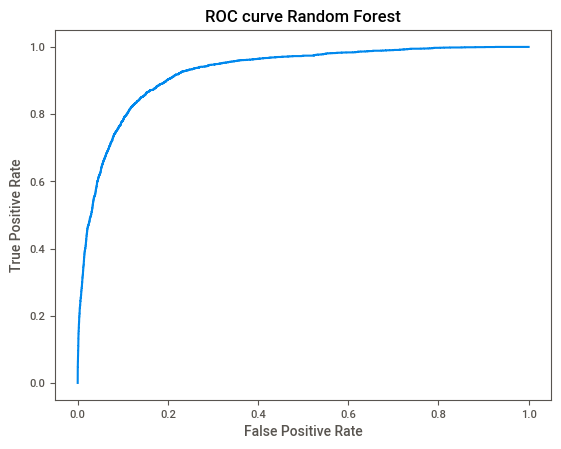

              precision    recall  f1-score   support

           0       0.97      0.80      0.88     11119
           1       0.55      0.90      0.68      3004

    accuracy                           0.82     14123
   macro avg       0.76      0.85      0.78     14123
weighted avg       0.88      0.82      0.84     14123



In [19]:
# predict probabilities of readmission
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_test)[:,1]

# plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve Random Forest')
plt.show()

# get classification report and tune threshold in such a way that recall is at least 0.9
threshold = 0.5
print(classification_report(y_test, y_pred > threshold))


In [20]:
print(f" In a group of 1000 individuals approximately {sum(y_pred > threshold) / len(y_pred) * 1000:.0f} have a salary higher than 75k. Amongst these ... \n \
      \t ... {sum((y_test == 1) & (y_pred > threshold)) / len(y_pred) * 1000:.0f} are correctly classified; \n \
      \t ... {sum((y_test == 0) & (y_pred > threshold)) / len(y_pred) * 1000:.0f} are classified as not having a salary higher than 75k. \n \n \
Additionally, we expect that there are {sum((y_test == 1) & (y_pred < threshold)) / len(y_pred) * 1000:.0f} individuals who have a salary higher than 75k but are not classified as such.")

 In a group of 1000 individuals approximately 347 have a salary higher than 75k. Amongst these ... 
       	 ... 191 are correctly classified; 
       	 ... 155 are classified as not having a salary higher than 75k. 
 
 Additionally, we expect that there are 21 individuals who have a salary higher than 75k but are not classified as such.


In [21]:
len(y_pred)

14123

### Using Lasso Regression as an interpretable model
---

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lasso = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
    param_grid={'C': [0.01, 0.1, 1.0, 10.0]},  # C = inverse of regularization strength
    cv=5, scoring='accuracy'
)
lasso.fit(X_train_scaled, y_train)
print(f"Lasso Tuned (best C={lasso.best_params_['C']}):")
print(classification_report(y_test, lasso.predict(X_test_scaled)))


C:\Users\prabnoor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


**Alternative**: Simply fit the model with the parameters found above

In [ ]:
lasso = LogisticRegression(C=1 , penalty='l1', solver='liblinear', random_state=42)
lasso.fit(X_train_scaled, y_train)
print("Lasso:")
print(classification_report(y_test, lasso.predict(X_test_scaled)))

In [ ]:
lasso_params = lasso.coef_
lasso_intercept = lasso.intercept_

feature_names = X_train.columns

lasso_coef_table = pd.DataFrame({
    "Feature": ["Intercept"] + list(feature_names),
    "Coefficient": [lasso.intercept_[0]] + list(lasso.coef_[0])
})

lasso_coef_table["Coefficient"] = lasso_coef_table["Coefficient"].round(3)
lasso_coef_table = lasso_coef_table.set_index("Feature")

lasso_coef_table.style.background_gradient(cmap="viridis")

### Exploration of fairness
---
Given 4 groups we constructed, we look at these fairness measures:
1. Demographic Parity
2. True Positive Rate
3. False Positive Rate

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
sensitive_groups = {
    'under30': data['AGEGRP'] <= 9,
    'thirdgenorhigher': data['GENSTAT'] == 4,
    'isacitizen': data['Citizen'] != 3,
    'isreligious': data['RELIGION_DER'] != 22,  # not religious
    'Gender_Female': data['Gender'] == 1,
}

In [ ]:
y_pred_rf = rf.predict(X_test)           # black-box random forest
y_pred_lasso = lasso.predict(X_test_scaled)  # interpretable lasso

# Get the sensitive group values for test set
test_idx = X_test.index
sensitive_test = {k: v.loc[test_idx] for k, v in sensitive_groups.items()}

In [ ]:
def fairness_metrics(y_true, y_pred, group_mask):
    """Returns TPR, FPR, selection rate for a group vs complement."""
    results = {}
    for group_name, mask in group_mask.items():
        for group_val, label in [(True, group_name), (False, f'non_{group_name}')]:
            idx = mask == group_val
            if idx.sum() == 0:
                continue
            yt = y_true[idx]
            yp = y_pred[idx]
            tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # equal opportunity
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # predictive equality
            sr  = (tp + fp) / len(yp)                       # demographic parity
            results[label] = {'TPR': tpr, 'FPR': fpr, 'Selection Rate': sr, 'n': idx.sum()}
    return pd.DataFrame(results).T

In [ ]:
metrics_rf    = fairness_metrics(y_test.values, y_pred_rf,    sensitive_test)
metrics_lasso = fairness_metrics(y_test.values, y_pred_lasso, sensitive_test)

print("=== Random Forest ===")
print(metrics_rf.round(3))
print("\n=== Lasso ===")
print(metrics_lasso.round(3))

Demographic Parity (Selection Rate)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, (metrics, title) in zip(axes, [
    (metrics_rf, 'Random Forest'),
    (metrics_lasso, 'Lasso Logistic Regression')
]):
    metrics['Selection Rate'].plot(kind='barh', ax=ax, color='steelblue')
    ax.axvline(x=y_test.mean(), color='red', linestyle='--', label='Overall rate')
    ax.set_title(f'Demographic Parity — {title}')
    ax.set_xlabel('Selection Rate (P(ŷ=1))')
    ax.legend()

plt.tight_layout()
plt.savefig('demographic_parity.png', dpi=150, bbox_inches='tight')
plt.show()

Equal Opportunity (TPR)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, (metrics, title) in zip(axes, [
    (metrics_rf, 'Random Forest'),
    (metrics_lasso, 'Lasso Logistic Regression')
]):
    metrics['TPR'].plot(kind='barh', ax=ax, color='darkorange')
    ax.set_title(f'Equal Opportunity (TPR) — {title}')
    ax.set_xlabel('True Positive Rate')

plt.tight_layout()
plt.savefig('equal_opportunity.png', dpi=150, bbox_inches='tight')
plt.show()

Side-by-side comparison RF vs Lasso

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric in zip(axes, ['Selection Rate', 'TPR', 'FPR']):
    x = np.arange(len(metrics_rf))
    width = 0.35
    ax.bar(x - width/2, metrics_rf[metric],    width, label='Random Forest', color='steelblue')
    ax.bar(x + width/2, metrics_lasso[metric], width, label='Lasso',         color='darkorange')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_rf.index, rotation=45, ha='right')
    ax.set_title(metric)
    ax.legend()

plt.suptitle('Fairness Metrics: RF vs Lasso', fontsize=14)
plt.tight_layout()
plt.savefig('fairness_comparison.png', dpi=150, bbox_inches='tight')
plt.show()